Problem statement: Understand the reasons for income of human beings in the dataset being <=50k or >50k

## Import libraries

In [ ]:
## Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

## Upload dataset

In [ ]:
df = pd.read_csv('/content/Humans dataset.csv')

## Basic data inspection

In [ ]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0.0,4356.0,40.0,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0.0,4356.0,18.0,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0.0,4356.0,40.0,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0.0,3900.0,40.0,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0.0,3900.0,40.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19163,19,Private,35245,HS-grad,9,Never-married,Transport-moving,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
19164,36,Private,167482,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
19165,41,Private,204662,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,45.0,United-States,>50K
19166,32,Private,291147,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K


In [ ]:
## Check the shape of the dataset

df.shape

(19168, 15)

In [ ]:
## Check the basic info of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19168 entries, 0 to 19167
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             19168 non-null  int64  
 1   workclass       19168 non-null  object 
 2   fnlwgt          19168 non-null  int64  
 3   education       19168 non-null  object 
 4   education.num   19168 non-null  int64  
 5   marital.status  19168 non-null  object 
 6   occupation      19168 non-null  object 
 7   relationship    19167 non-null  object 
 8   race            19167 non-null  object 
 9   gender          19167 non-null  object 
 10  capital.gain    19167 non-null  float64
 11  capital.loss    19167 non-null  float64
 12  hours.per.week  19167 non-null  float64
 13  native.country  19167 non-null  object 
 14  income          19167 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 2.2+ MB


In [ ]:
## Basic statistical analysis

df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,19168.000000,1.916800e+04,19168.000000,19167.000000,19167.000000,19167.000000
mean,39.048205,1.900383e+05,10.188178,1830.715501,148.312203,40.738039
std,13.665376,1.050809e+05,2.585000,9554.078563,516.530691,12.294738
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.187100e+05,9.000000,0.000000,0.000000,40.000000
50%,38.000000,1.783705e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.378685e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Null value check

In [ ]:
## Check null values in the dataset

df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,1
race,1
gender,1


## Duplicates check

In [ ]:
## Duplicates check

df.duplicated().sum()

np.int64(7)

In [ ]:
## Drop the duplicates

df.drop_duplicates(inplace=True)

In [ ]:
## find the shape of dataset

df.shape

(19161, 15)

## Split the data into categorical and numerical columns

In [ ]:
## split the data into the categorical and numerical data

categorical_columns = df.select_dtypes(include = 'object').columns
numerical_columns = df.select_dtypes(exclude = 'object').columns

In [ ]:
categorical_columns

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'gender', 'native.country', 'income'],
      dtype='object')

In [ ]:
numerical_columns

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

In [ ]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0.0,4356.0,40.0,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0.0,4356.0,18.0,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0.0,4356.0,40.0,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0.0,3900.0,40.0,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0.0,3900.0,40.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19163,19,Private,35245,HS-grad,9,Never-married,Transport-moving,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
19164,36,Private,167482,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
19165,41,Private,204662,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,45.0,United-States,>50K
19166,32,Private,291147,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K


In [ ]:
## Count the values in each of the categories

for i in categorical_columns:
  print(df[i].value_counts())
  print('--'*50)

workclass
Private             13239
Self-emp-not-inc     1563
Local-gov            1227
?                    1053
State-gov             768
Self-emp-inc          718
Federal-gov           584
Without-pay             6
Never-worked            3
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
education
HS-grad         6104
Some-college    4203
Bachelors       3305
Masters         1115
Assoc-voc        818
11th             663
Assoc-acdm       611
10th             516
Prof-school      392
7th-8th          364
9th              281
Doctorate        275
12th             216
5th-6th          183
1st-4th           91
Preschool         24
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
marital.status
Married-civ-spouse       9202
Never-married            6018
Divorced                 2531
Widowed                   581
Separated            

## Handling error "?" values in the dataset

In [ ]:
## Find out how many "?" are there in any columns

df.isin(['?']).sum()

,0
age,0
workclass,1053
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1056
relationship,0
race,0
gender,0


In [ ]:
## replace all "?" values with Null values

df.replace('?', np.nan, inplace= True)

In [ ]:
## Find out how many "?" are there in any columns

df.isin(['?']).sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
## Lets recheck the null values
# there is the null values contains in the workclass,occupation,capital.gain,capital.loss,hours.per.week,native.country we have to manage them

df.isnull().sum()

,0
age,0
workclass,1053
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1056
relationship,1
race,1
gender,1


In [ ]:
## Here in the hours.per.week column we have the null values but the column contains the int type of data then we find the mean of the column
df['hours.per.week'].mean()

np.float64(40.741179540709815)

In [ ]:
# we can fill/handale the null values by the function with mean values that we have obtain
for col in ['hours.per.week']:
  df[col].fillna(df[col].mean(), inplace=True)

In [ ]:
#  Here in the 'capital.gain' column we have the null values but the column contains the int type of data
#  then we find the mean of the column

df['capital.gain'].mean()


np.float64(1831.3843423799583)

In [ ]:
#  Here in the 'capital.loss' column we have the null values but the column contains the int type of data
#  then we find the mean of the column

df['capital.loss'].mean()

np.float64(148.36638830897704)

In [ ]:
# we can fill/handale the null values by the function with mean values that we have obtain
for col in ['capital.gain','capital.loss']:
  df[col].fillna(df[col].mean(), inplace=True)

In [ ]:
df['capital.loss']

,capital.loss
0,4356.000000
1,4356.000000
2,4356.000000
3,3900.000000
4,3900.000000
...,...
19163,0.000000
19164,0.000000
19165,0.000000
19166,0.000000


In [ ]:
#same as for this find the mode beacuse of the the data is the categorical type
df['native.country'].mode()[0]

'United-States'

In [ ]:
df['occupation'].mode()[0]

'Prof-specialty'

In [ ]:
# fill the null values by the obtaines mode value
for col in ['workclass', 'native.country', 'occupation']:
  df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:
## Lets recheck the null values

df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,1
race,1
gender,1


## Univariate analysis

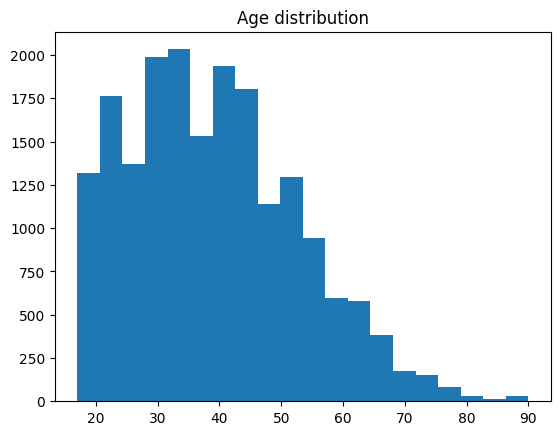

In [ ]:
## Age distribution
# here the the histogram shows that the from the 10 to 45 age group of the count is the maximum

plt.hist(df["age"], bins= 20)
plt.title("Age distribution")
plt.show()

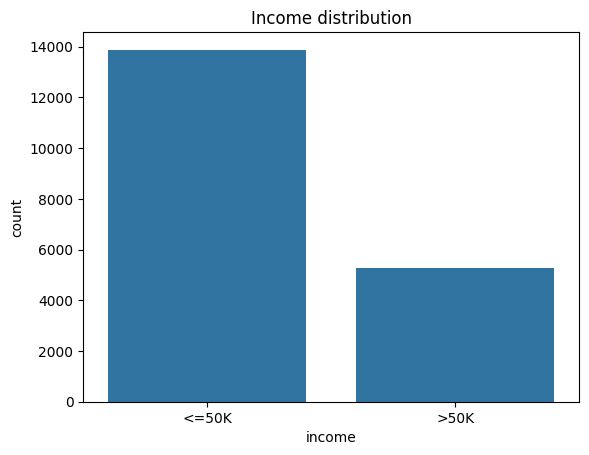

In [ ]:
## Income distribution

#It shows that the <=50K income of the peoples are the maximum than the >50k income

sns.countplot(x = "income", data = df)
plt.title("Income distribution")
plt.show()

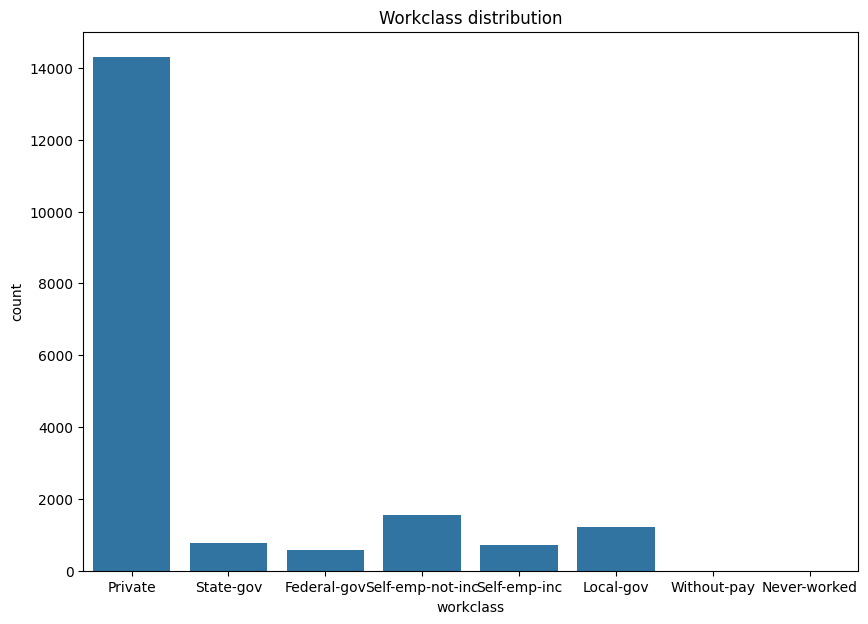

In [ ]:
## Workclass distribution
#Here the Highset number of peoples are work in the private sector and then second highest one is self-employed

plt.figure(figsize = (10, 7))
sns.countplot(x = "workclass", data = df)
plt.title("Workclass distribution")
plt.show()

## Bivariate analysis

In [ ]:
numerical = df.select_dtypes(exclude = 'object')

In [ ]:
numerical

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
0,90,77053,9,0.000000,4356.000000,40.00000
1,82,132870,9,0.000000,4356.000000,18.00000
2,66,186061,10,0.000000,4356.000000,40.00000
3,54,140359,4,0.000000,3900.000000,40.00000
4,41,264663,10,0.000000,3900.000000,40.00000
...,...,...,...,...,...,...
19163,19,35245,9,0.000000,0.000000,40.00000
19164,36,167482,13,0.000000,0.000000,40.00000
19165,41,204662,14,0.000000,0.000000,45.00000
19166,32,291147,10,0.000000,0.000000,50.00000


In [ ]:
numerical.corr()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
age,1.000000,-0.080700,0.038749,0.095315,0.066646,0.057066
fnlwgt,-0.080700,1.000000,-0.044245,0.000095,-0.014361,-0.011875
education.num,0.038749,-0.044245,1.000000,0.152329,0.093435,0.158235
capital.gain,0.095315,0.000095,0.152329,1.000000,-0.055043,0.098709
capital.loss,0.066646,-0.014361,0.093435,-0.055043,1.000000,0.065145
hours.per.week,0.057066,-0.011875,0.158235,0.098709,0.065145,1.000000


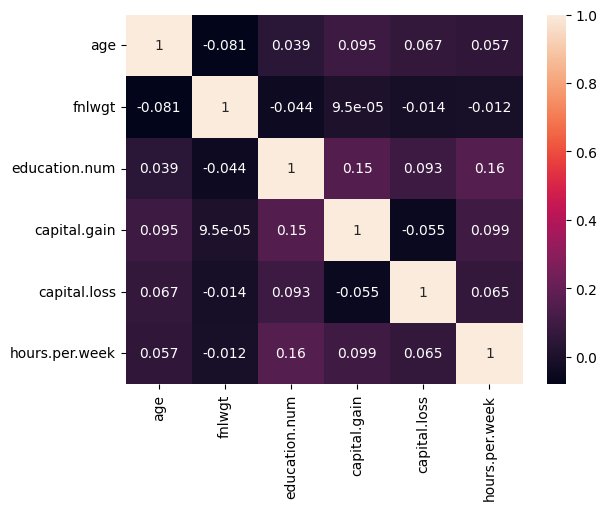

In [ ]:
## Correlation
# Representaion of the coreelation of the each columns that are the correlate to each other

sns.heatmap(numerical.corr(), annot = True)
plt.show()

## Outlier detection:

1. Detect the outliers: boxplot, histogram
2. Remove the outliers:
* a. IQR (boxplot method)
* b. Z-score method





In [ ]:
numerical_columns

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

### 1. Box plot(IQR) method




In [ ]:
outliers_iqr = {}

In [ ]:
for col in numerical_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  df_iqr = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

  outliers_iqr[col] = len(outliers)

  print("Original Shape: ", df.shape)
  print("New Shape: ", df_iqr.shape)
  print("--"*50)

Original Shape:  (19161, 15)
New Shape:  (19075, 15)
----------------------------------------------------------------------------------------------------
Original Shape:  (19161, 15)
New Shape:  (18598, 15)
----------------------------------------------------------------------------------------------------
Original Shape:  (19161, 15)
New Shape:  (19046, 15)
----------------------------------------------------------------------------------------------------
Original Shape:  (19161, 15)
New Shape:  (16448, 15)
----------------------------------------------------------------------------------------------------
Original Shape:  (19161, 15)
New Shape:  (17641, 15)
----------------------------------------------------------------------------------------------------
Original Shape:  (19161, 15)
New Shape:  (13909, 15)
----------------------------------------------------------------------------------------------------


### Z-score method for outliers

#### Reload the dataset, then only proceed with the z-score method for outlier removal

In [ ]:
numerical_columns

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

In [ ]:
from scipy import stats

In [ ]:
z_score = np.abs(stats.zscore(df[numerical_columns]))

In [ ]:
outliers = (z_score > 3).any(axis = 1) | (z_score < -3).any(axis = 1)

print("Number of outliers using Z-score: ", len(df[outliers]))

Number of outliers using Z-score:  1866


In [ ]:
## Removal of outliers using Z-score

df_zscore = df[(z_score < 3).all(axis=1)]

print("Original shape: ", df.shape)
print("New shape: ", df_zscore.shape)

Original shape:  (19161, 15)
New shape:  (17295, 15)


In [ ]:
df_zscore

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,capital.gain,capital.loss,hours.per.week,native.country,income
1121,32,Private,110331,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,1672.000000,60.00000,United-States,<=50K
1122,50,Self-emp-inc,175339,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0.000000,1672.000000,60.00000,United-States,<=50K
1123,31,Private,59083,Some-college,10,Married-civ-spouse,Other-service,Husband,White,Male,0.000000,1672.000000,50.00000,United-States,<=50K
1125,34,Private,80933,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0.000000,1672.000000,40.00000,United-States,<=50K
1126,34,Private,119422,Assoc-voc,11,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.000000,1672.000000,50.00000,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19163,19,Private,35245,HS-grad,9,Never-married,Transport-moving,Own-child,White,Male,0.000000,0.000000,40.00000,United-States,<=50K
19164,36,Private,167482,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0.000000,0.000000,40.00000,United-States,>50K
19165,41,Private,204662,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.000000,45.00000,United-States,>50K
19166,32,Private,291147,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0.000000,0.000000,50.00000,United-States,<=50K


# **Conversionn of the categorial data into the numerical data**

In [ ]:
categorical_columns


Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'gender', 'native.country', 'income'],
      dtype='object')

In [ ]:
#Education is the column that has the ordinal type of data therefore we find the values of it

print(df['education'])

0             HS-grad
1             HS-grad
2        Some-college
3             7th-8th
4        Some-college
             ...     
19163         HS-grad
19164       Bachelors
19165         Masters
19166    Some-college
19167         HS-grad
Name: education, Length: 19161, dtype: object


In [ ]:
#find the only uniqe values in the column for the converting the in the form of the numerical data
#By the method of the ordinalencoder
#Education colmun is the ordinal type of the data
print(df['education'].unique())

['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool']


In [ ]:
#import the sklearn libraries to use of the label encoder and ordinal encoder

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

In [ ]:
#Here we give the sequence of the data to provide the ordinal encoder
order = [[
'Preschool',
'1st-4th',
'5th-6th',
'7th-8th',
'9th',
'10th',
'11th',
'12th',
'HS-grad',
'Some-college',
'Assoc-voc',
'Assoc-acdm',
'Bachelors',
'Masters',
'Prof-school',
'Doctorate'
]]

In [ ]:
#fit the ordinal encoder
oe = OrdinalEncoder(categories = order)

In [ ]:
#Transform the column of the education in the ordinal encoder first
df['education'] = oe.fit_transform(df[['education']])

In [ ]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,8.0,9,Widowed,Prof-specialty,Not-in-family,White,Female,0.000000,4356.000000,40.00000,United-States,<=50K
1,82,Private,132870,8.0,9,Widowed,Exec-managerial,Not-in-family,White,Female,0.000000,4356.000000,18.00000,United-States,<=50K
2,66,Private,186061,9.0,10,Widowed,Prof-specialty,Unmarried,Black,Female,0.000000,4356.000000,40.00000,United-States,<=50K
3,54,Private,140359,3.0,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0.000000,3900.000000,40.00000,United-States,<=50K
4,41,Private,264663,9.0,10,Separated,Prof-specialty,Own-child,White,Female,0.000000,3900.000000,40.00000,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19163,19,Private,35245,8.0,9,Never-married,Transport-moving,Own-child,White,Male,0.000000,0.000000,40.00000,United-States,<=50K
19164,36,Private,167482,12.0,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0.000000,0.000000,40.00000,United-States,>50K
19165,41,Private,204662,13.0,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.000000,45.00000,United-States,>50K
19166,32,Private,291147,9.0,10,Married-civ-spouse,Sales,Husband,White,Male,0.000000,0.000000,50.00000,United-States,<=50K


In [ ]:
#fit the label encoder
le = LabelEncoder()

In [ ]:
# transform the label encoder only except the education column beacuse of the it alredy converted into the numbers
for col in df.columns:
    if col != 'education' and df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,3,77053,8.0,9,6,10,1,4,0,0.000000,4356.000000,40.00000,38,0
1,82,3,132870,8.0,9,6,4,1,4,0,0.000000,4356.000000,18.00000,38,0
2,66,3,186061,9.0,10,6,10,4,2,0,0.000000,4356.000000,40.00000,38,0
3,54,3,140359,3.0,4,0,7,4,4,0,0.000000,3900.000000,40.00000,38,0
4,41,3,264663,9.0,10,5,10,3,4,0,0.000000,3900.000000,40.00000,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19163,19,3,35245,8.0,9,4,14,3,4,1,0.000000,0.000000,40.00000,38,0
19164,36,3,167482,12.0,13,2,0,0,4,1,0.000000,0.000000,40.00000,38,1
19165,41,3,204662,13.0,14,2,4,0,4,1,0.000000,0.000000,45.00000,38,1
19166,32,3,291147,9.0,10,2,12,0,4,1,0.000000,0.000000,50.00000,38,0
